\newpage
## Introducción

El presente proyecto se centra en el análisis numérico de la serie temporal del índice bursátil NASDAQ-100 durante el período comprendido entre octubre de 2019 y octubre de 2024. El objetivo de este estudio es aplicar métodos numéricos para transformar los registros históricos de cierre diario, los cuales presentan alta volatilidad, en un modelo matemático continuo.

Para garantizar la estabilidad de los cálculos computacionales, el conjunto de datos fue sometido a un proceso de normalización. Trabajar con las cifras originales que se encuentran en el orden de los miles, al calcular matrices y polinomios de grado superior suele provocar errores de redondeo o desbordamiento en la memoria del sistema. Al reducir la escala a valores normalizados y transformar las fechas calendario en una variable numérica continua, el algoritmo puede procesar la información de manera más eficiente, similar a cómo se grafica un punto en un plano cartesiano simple. 

Este enfoque permitió filtrar el ruido diario del mercado bursátil para evaluar la reacción real del activo frente a eventos económicos recientes así proyectar su tendencia a futuro mediante algoritmos de búsqueda de raíces.


## Objetivos

* Describir los precios de cierre normalizados mediante la inteporlación por splines cúbicos para disminuir el ruido en los datos y obtener una curva continua.
* Generar un polinomio de aproximación a la curva a través de regresión polinómica usando mínimos cuadrados para describir el comportamiento del índice NASDAQ en la ventana de tiempo analizado.
* Calcular el momento en el que el índice alcance el precio de cierre normalizado por medio del método de Newton-Raphson para un análisis de contraste y predicción.

## Marco Teórico

Para el desarrollo del modelo predictivo se implementaron tres métodos numéricos secuenciales. Cada uno cumple una función específica dentro del flujo de procesamiento de la señal financiera:

### 1. Interpolación por Splines Cúbicos
Es un método numérico que permite construir una curva continua y suave [@scienceDirect] conectando un conjunto discreto de puntos mediante polinomios de tercer grado por tramos. En el contexto financiero de este proyecto, el spline actúa como un filtro de ruido. En lugar de conectar variaciones extremas y erráticas de precios diarios con líneas rectas, genera una trayectoria fluida. De forma práctica, funciona como si se utilizara una plantilla curva (cercha) para trazar la línea que mejor une los puntos, revelando el comportamiento subyacente del mercado sin alteraciones bruscas.

### 2. Regresión por Mínimos Cuadrados
Es una técnica de optimización que busca la curva de tendencia central para un conjunto de datos. En este análisis, se emplea para construir un polinomio de grado $n$ que describa el historial de precios. El método minimiza el error cuadrático entre los puntos suavizados por los splines y la línea del modelo. Computacionalmente, esto se logra armando una matriz de Vandermonde [@vandermonde; @vandermonde_maiz]($A$) y resolviendo el sistema de ecuaciones normales: 
$(A^T A)x = A^T y$
Este proceso reduce la sobre-determinación del sistema (de miles de ecuaciones a una matriz cuadrada manejable), entregando los coeficientes del polinomio de mejor ajuste.

### 3. Método de Newton-Raphson
Es un algoritmo iterativo de búsqueda de raíces basado en aproximaciones lineales usando una recta tangente la curva en un punto inicial o semilla ($t_0$) [@newtonMethod], se traza con la tangente y se observa el cruce con el eje horizontal, repitiendo el proceso hasta converger en la raíz exacta. La iteración se rige por la ecuación:
$t_{n+1} = t_n - \frac{f(t_n)}{f'(t_n)}$
En este modelo, se redefine la función objetivo como $f(t) = P(t) - objetivo$, permitiendo encontrar el día exacto ($t$) en que la tendencia polinomial alcanza el puntaje esperado.

### 4. Variables del Dataset
El dataset recopila datos historicos en una serie de tiempo discreta con frecuencia de muestreo diario, tomando en cuenta solo los dias de operación. Los datos bursátiles provienen de indicadores macroeconómicos y del repositorio público de Kaggle [@kaggle]. Fue indispensable verificar que este subconjunto de datos mantuviera la continuidad temporal y contuviera todas las variables técnicas necesarias. Este dataset representa la interacción analítica entre el rendimiento de las empresas teconológicas de mayor capitalización y las fuerzas económicas externas que las gobiernan. Además, incorpora métricas de volatilidad implícita, tasas de interés y activos de refugio económico, lo que permite construir un sistema numérico coherente y cerrado. Esta estructura resulta especialmente adecuada para los tres ejes del proyecto: modelado, interpolación y resolución de sistemas lineales acoplados.
El rango temporal seleccionado abarca desde octubre de 2019 hasta octubre de 2024, lo que equivale a aproximadamente 1.260 registros continuos.

* **Date (Fecha):** Es la variable independiente $x$, la cual registra la fecha de cada jornada
en formato AAAA-MM-DD. Para los cálculos, esta columna se transforma en un vector
de enteros consecutivos donde $x_0 = 0$ corresponde al primer día hábil de octubre de 2019 y $x_n \approx 1260$ al cierre del periodo.
* **Close (Precio de cierre):** Es la variable dependiente $y$, es el valor en dólares al que
cerró el índice NASDAQ-100 cada jornada. Es la variable sobre la que se ajusta el polinomio de segundo grado mediante mínimos cuadrados, y también la función continua sobre la que Newton-Raphson aproxima derivadas locales para identificar puntos de resistencia técnica, suele ser usado como indicador para predicción de tendencias [@indicesBursatiles].

## Prerrequisitos

La implementación del modelo numérico requiere la siguiente infraestructura y herramientas de software:

* **Entorno de Desarrollo:** el control de versiones a través de GitHub permitió que cada integrante trabaje en el entorno de desarrollo con el que se sienta más cómodo. Esto permitió la integración directa entre entornos de desarrollo virtuales como VSCode y entornos en la nube como Google Colab sin tener ningún problema durante la implementación. Además, se usó Python como lenguaje estándar de programación a través de Jupyter Notebooks.
* **Librerías Fundamentales:** se trabajaron librerías estándar como `Numpy` por el poder que ofrece para trabajar con funciones y operaciones matemáticas. De igual modo se trabajó con `Pandas` y `Matplotlib` que suelen ser el estándar por excelencia para el manejo de grandes volúmenes de datos y su visualización.

## Desarrollo

La construcción del modelo numérico para el índice NASDAQ-100 se realizó siguiendo una metodología secuencial, utilizando el lenguaje de programación Python por su versatilidad y el uso de librerías de cálculo matricial como NumPy y Pandas. A continuación, se detalla la lógica matemática y algorítmica aplicada en el proyecto: 

### Fase 1: Preprocesamiento y Linealización Temporal

Antes de aplicar los algoritmos de interpolación o estimación, fue indispensable llevar a cabo una fase exhaustiva de preprocesamiento, dado que la presencia de ruidos temporales o formatos inadecuados puede distorsionar la validez del modelo matemático. Durante la carga inicial del archivo de datos, se identificó que las fechas calendario poseían un formato cualitativo imposible de operar algebraicamente.

Para solucionar este inconveniente y linealizar el eje del tiempo, se creó la variable independiente t, la cual asigna un valor numérico secuencial a cada registro. Este proceso garantizó que cada incremento unitario equivalga exactamente a un día hábil de operación bursátil, eliminando los espacios vacíos de los fines de semana y feriados que deformarían el análisis. Posteriormente, se extrajo la ventana temporal de interés correspondiente a un periodo de 5 años (octubre 2019 - octubre 2024). Para mitigar el riesgo de acumular pequeños errores de cálculo en las matrices durante fases posteriores, se aplicó una estandarización estricta por redondeo a 8 cifras decimales en la variable del precio de cierre. 

**Funciones implementadas**

* `pd.read_csv()` y `pd.to_datetime()`: Funciones utilizadas para importar el conjunto de datos original y convertir la columna de texto plano a un formato cronológico estructurado. 
* `np.arange()`: Función matemática implementada para generar la secuencia ordenada de números enteros y construir el índice continuo de días hábiles. 
* `.round(8)`: Método aplicado sobre el dataframe para estabilizar aritméticamente los precios de cierre a una precisión constante de 8 decimales. 

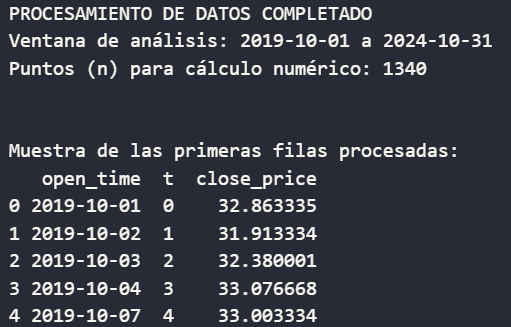

### Fase 2: División del dataset Train / Test

Para evitar el sobreajuste en el modelo, se realizó la etapa de validación de los datos debido a la dependencia temporal de las series financieras. En este caso se decidió trabajar con una proporción 80% para el subconjunto de entrenamiento y 20% para el subconjunto de prueba. La decisión de esta proporción se fundamenta en que se requiere sobre el 70% de muestras del datasest para conseguir los mejores resultados de rendimiento, precisión y sensibilidad al armar un modelo [@train_test_ratio].

**Funciones implementadas:**

* `len()` e `int()`: Funciones empleadas para determinar la longitud total de los vectores de datos y calcular el índice numérico exacto de corte.
* `.iloc[]`: Propiedad de Pandas implementada para localizar la fila exacta en el dataframe original donde finaliza el entrenamiento y arranca la prueba.  
* `.date()`: Método aplicado sobre el registro localizado en el dataframe para desechar la información de horas/minutos y extraer la fecha calendario.

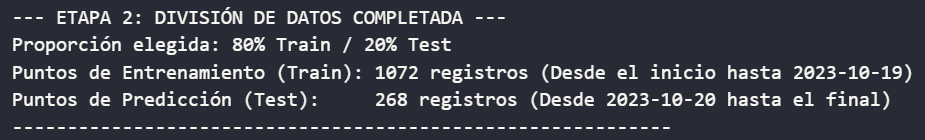

### Fase 3: Interpolación y Suavizado mediante Splines Cúbicos

Con el conjunto de datos purificado, el objetivo de esta etapa fue construir una trayectoria continua del índice bursátil, mitigando las fluctuaciones rápidas del mercado sin perder la memoria histórica original. Los datos limpios se extrajeron en arreglos unidimensionales nativos, definiendo a t como la variable independiente y al precio de cierre como la variable dependiente y, optimizándolos para el cálculo vectorial. 

Para el ajuste de la curva, se implementó el algoritmo de Spline Cúbico Natural. Al obligar matemáticamente a que la segunda derivada en las fronteras inicial y final del intervalo sea igual a cero, el modelo logra absorber las tensiones de la curva. Esto previene el Fenómeno de Runge, evitando que se generen oscilaciones falsas o exageradas en los extremos del análisis. Finalmente, la función matemática construida se evaluó sobre un espacio muestral altamente denso, permitiendo proyectar una representación visual suave que contrasta directamente con el ruido diario del mercado. 

**Funciones implementadas:**

* `CubicSpline(t, y, bc_type='natural')`: Es el núcleo algorítmico de la interpolación de la librería SciPy, utilizado para conectar los puntos de precio por tramos bajo condiciones de frontera estables (segunda derivada nula en los extremos). 
* `np.linspace()`: Función utilizada para crear una malla fina de 1000 puntos intermedios distribuidos uniformemente, generando el espacio denso necesario para la evaluación continua del polinomio. 
* `plt.plot()`: Constructores gráficos de Matplotlib empleados para trazar y superponer los datos reales (con opacidad reducida) junto con la curva verde del modelo continuo, facilitando el análisis visual del suavizado. 

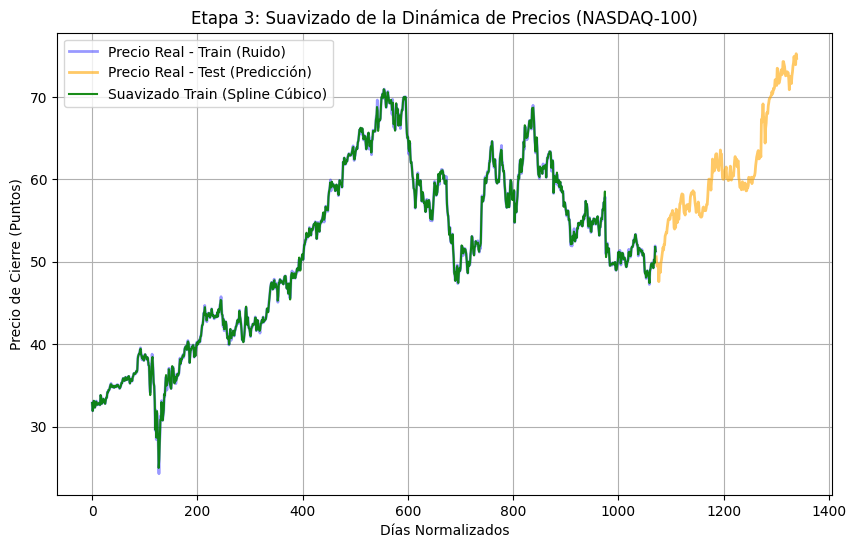

### Fase 4: Determinación de la tendencia

Para determinar la tendencia, se partió del principio de que el análisis de predicción en mercados bursátiles establece un modelo basado en la relación lineal entre las variables, posicionando al tiempo como variable independiente y a la métrica de precio como dependiente [@trend_following_part8]. Esto se fundamenta en que no es factible establecer un comportamiento estrictamente periódico en el mercado que pueda justificarse mediante funciones trigonométricas. Por tanto, la curva de tendencia buscada sigue la forma:

$P(x)=a_{n}x^{n}+a_{n-1}x^{n-1}+\dots +a_{2}x^{2}+a_{1}x+a_{0}$

Para este caso, la hipótesis inicial consideraba la existencia de 4 macroeventos económicos dentro de la ventana temporal del conjunto de datos, por lo que se propuso inicialmente un polinomio de grado 4. No obstante, se determinó un claro sobreajuste (overfitting) en la tendencia. Para solventarlo, se implementó un bloque iterativo que buscaba el mejor coeficiente de determinación $R^2$. Bajo esta lógica, el algoritmo de optimización sugería un polinomio cóncavo de grado 2; sin embargo, este tendía a decrecer exponencialmente hacia el infinito a partir de una fecha límite, lo cual resulta no tiene sentido económico para proyecciones de mercado. Por consiguiente, se simplificó el ajuste para trabajar con un polinomio de grado 1, ya que la simplicidad del modelo permite una mayor capacidad de generalización y previene el sobreajuste que se genera con polinomios de órdenes superiores [@predict_stock_prices].

**Funciones implementadas:**

* `np.zeros()`: Crea una matriz vacía que luego se llena con los coeficientes elevados a las disntintas potencias para armar el modelo.
* `np.transpose()`: Crea la matriz transpuesta de la matriz original, se usa después para reducir el tamaño de la matriz y su sobre-determinación.  
* `np.dot()`: Realiza el producto $A^T A$.  
* `np.linalg.solve()`: Resuelve el sistema de ecuaciones algebraico para obtener la curva de ajuste.
* `np.mean()` y `np.sum()`: Calculan el valor promedio y la sumatoria total de los datos. Miden qué tan lejos está la línea de predicción respecto a los precios reales, calculan el nivel de error y el $R^2$.
* `range()`: genera una lista iterativa de números dentro del bucle de optimización para disminuir el grado del polinomio.

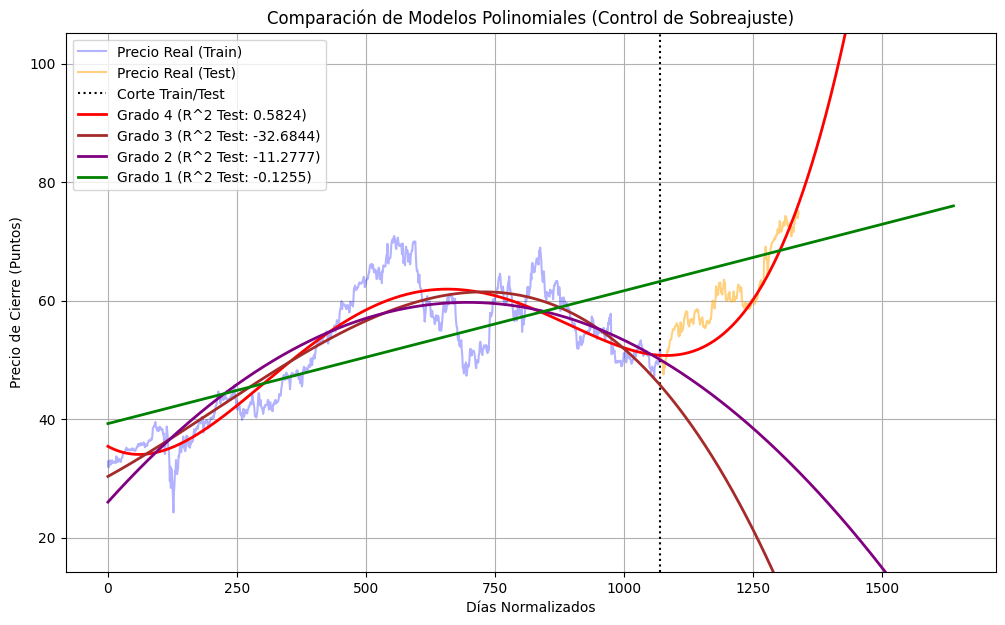

### Fase 5: Visualización de Proyecciones y Modelos

En esta última etapa, el objetivo fue consolidar gráficamente los resultados obtenidos en las fases analíticas previas. Dado que la ejecución del algoritmo de búsqueda de raíces mediante el método de Newton-Raphson se llevó a cabo durante la Fase 4 para calcular los cruces exactos sobre la tendencia, esta quinta fase se enfocó de manera exclusiva en el renderizado visual y la presentación del modelo final. El orquestador principal del programa recibió los parámetros procesados y los dirigío hacia los módulos de graficación para contrastar la predicción drente a los datos reales.

**Funciones implementadas:**

* `visualizar_historial_polinomios()`: Módulo encargado de graficar comparativamente los distintos modelos polinomiales evaluados para evidenciar visualmente el fénomeno y control del sobreajuste.
* `visualizar_proyeccion()`: Función responsable de desplegar la gráfica final con la curva de regresión lineal proyectada sobre el segmento de prueba(test), permitiendo observar claramente el comportamiento futuro estimado de la serie.

### Análisis de resultados

Tras la ejecución de las fases iniciales de preprocesamiento e interpolación, el análisis visual y cuantitativo confirma el éxito técnico del modelo propuesto en esta primera etapa. La superposición gráfica demuestra que el algoritmo logró transformar una extensa serie de datos financieros dispersos, caracterizados por el alto "ruido" y la volatilidad diaria en una función matemática continua, fluida y coherente. Este resultado garantiza que el conjunto de datos es ahora una estructura matemáticamente manejable.

Adicionalemente, la etapa de determinación de tendencia comprobó de manera empírica el riesgo del sobreajuste (overfitting) en el pronóstico de series de tiempo bursátiles. Al implementar polinomios de grados superiores (tales como grado 3 o 4), el modelo lograba un ajuste inicial atractivo sobre los datos de entrenamiento, pero tendía a decrecer drásticamente hacia el infinito al proyectarse en el segmento de prueba, perdiendo toda validez económica. La optimización del sistema para utilizar un polinomio de grado 1 demostró ser la estrategia matemáticamente más estable, previniendo el sobreajuste y entregando una capacidad de generalizacón realista para el mercado.

A nivel de arquitectura de software, el desarrollo secuencial administrado por el orquestador principal funcionó de manera óptima. Este diseño permitió que cada bloque del flujograma funcional recibiera, procesara y retornara los datos correctamente a la siguiente fase sin pérdida de precisión. Gracias a la aplicación oportuna del método de Newton-Raphson en la linealización de la variable tiempo (t) y el filtrado mediante splines cúbicos, el sistema en su totalidad proporciona una herramienta analítica robusta para estimar el comportamiento a futuro del índice NASDAQ-100

### Flujograma funcional

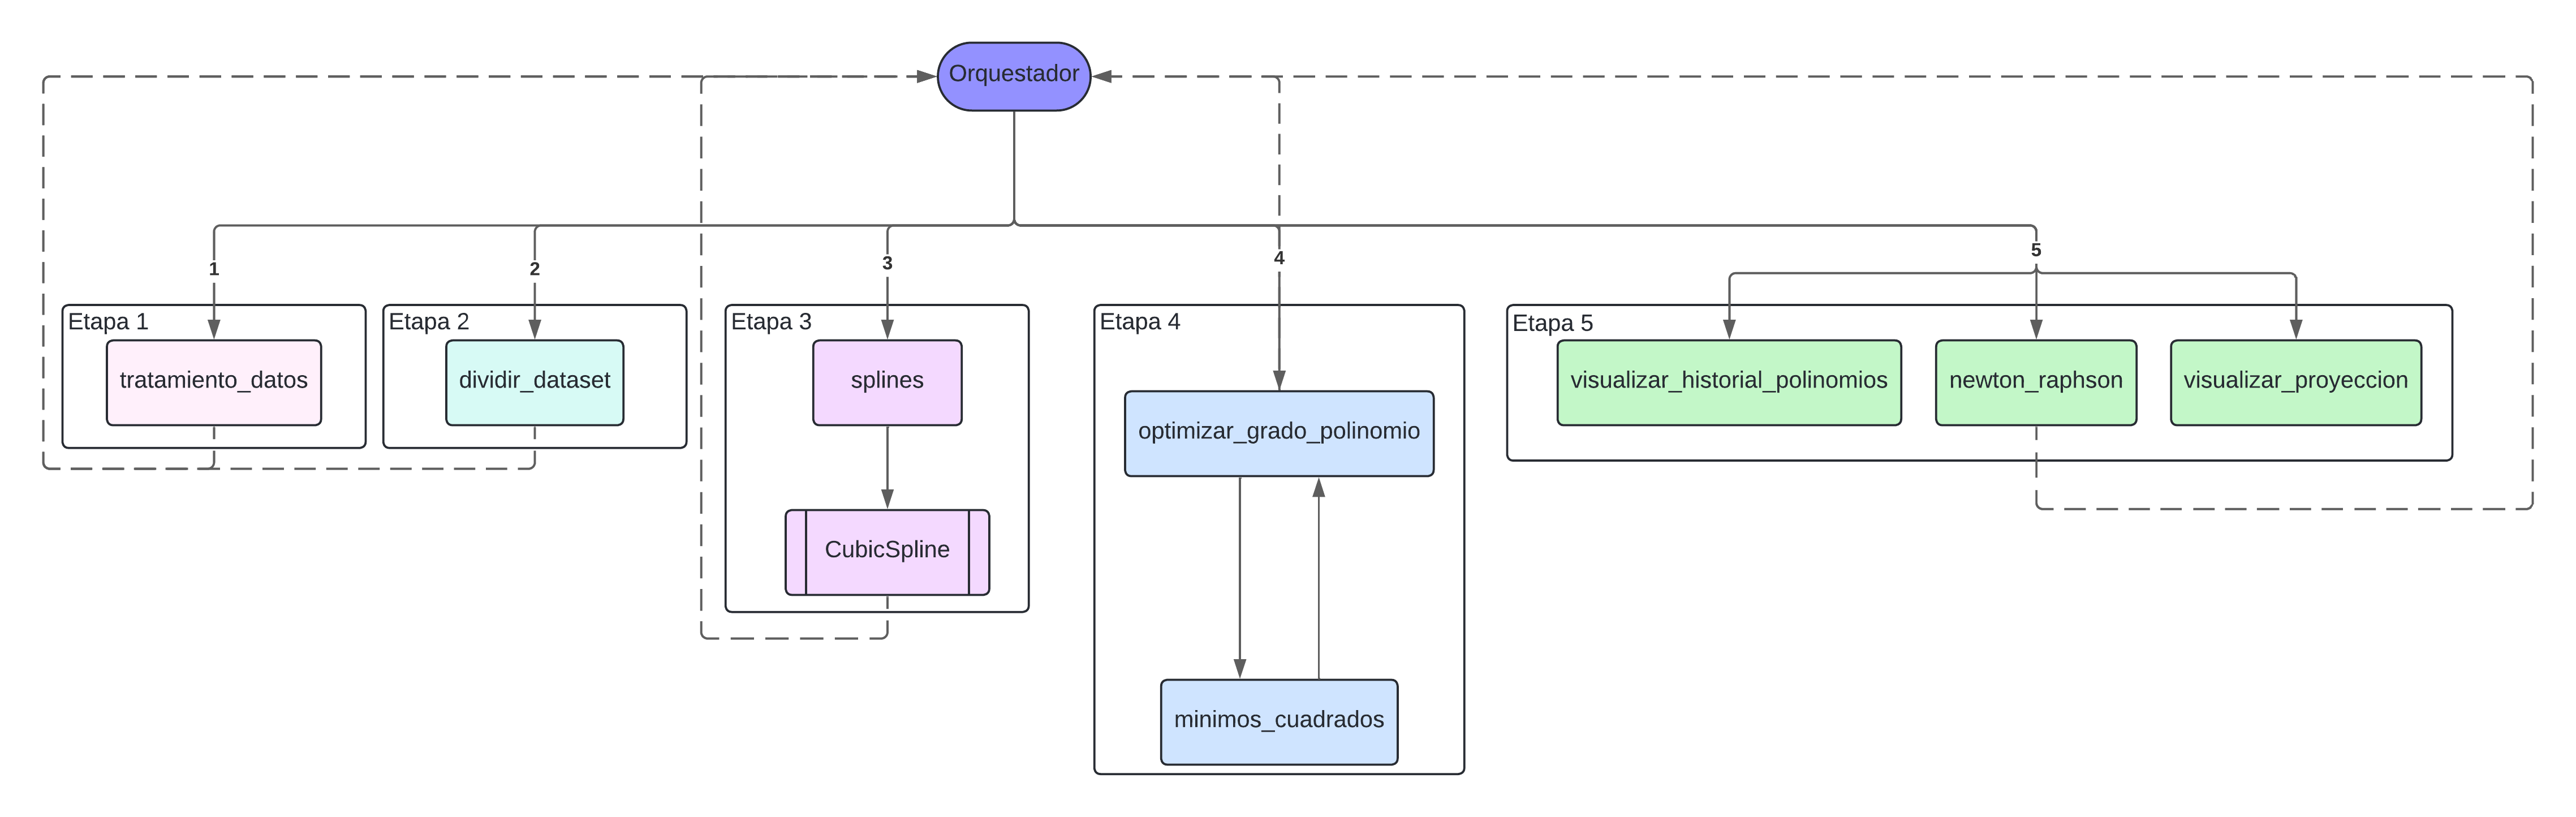

Como se puede observar, el proyecto fue implementado a través de un orquestador principal que es el encargado de comunicar cada etapa, este recibe los resultados de cada función y los envía a la etapa siguiente para que sean operados y devueltos.

### Repositorio y estadísticas

**TODO**: Incluir al finalizar


## Conclusiones

Se determinó que es importante mantener un control en las variables, al linealizar el tiempo $t$ se logró la establidad del modelo y su aplicación para conseguir un modelo de predicción que se mantiene simple. Al mismo tiempo se destaca la separación en etapas, ya que el suavizado del ruido mediante splines cúbicos mitigó el ruido de los datos que posteriormente se usaron para determinar la curva de regresión lineal mediante mínimos cuadrados.

La consolidación gráfica de los modelos demostró ser una herramienta analílitca indispensable para contrastar de manera directa el comportamiento real y volátil del mercado frente a las proyecciones suavizadas por el algoritmo numérico.

## Recomendaciones

* Se puede optimizar el costo y rendimiento computacional en futuras ejecuciones del modelo a través de la segmentación de los datos en ventanas de tiempo más cortas. Lo que simplificaría también los modelos matriciales y los tiempos de compilación sin perder precisión en el análisis.
* El modelo podría ser aplicado a otros índices bursátiles para evaluar su desempeño según el volumen de datos que se ingrese.
* Se puede facilitar el análisis visual en futuras iteraciones del código a través de la implementación de librerías de graficación interactiva. Lo que facilitaría la exploración detallada de los de tendencia mediante herramientas de acercamiento sin alterar el código base.

\newpage
## Referencias
:::{#refs}
:::